This notebook is used to explore and valudate the node features used in the project 

In [6]:
from pathlib import Path
import os

ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent
os.chdir(ROOT)
print("anchored at:", ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features.node_features import (
    to_wide, build_features, rebalance_dates, standardise,
)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

anchored at: /Users/tony/Library/Mobile Documents/com~apple~CloudDocs/equity-graph-clustering


Load the cached data panel 

In [8]:
panel = pd.read_parquet("data/processed/panel.parquet")
wide  = to_wide(panel)
ret   = wide["log_ret"]

feats = build_features(wide)                 # RAW, pre-standardisation
dates = rebalance_dates(ret.index)

print(f"sessions       : {len(ret):,}")
print(f"tickers        : {ret.shape[1]}")
print(f"rebalance dates: {len(dates)}  ({dates[0].date()} -> {dates[-1].date()})")
print(f"features built : {len(feats)}")

  wide frames: 105 tickers x 2929 sessions (2015-01-02 to 2026-08-26)
sessions       : 2,929
tickers        : 105
rebalance dates: 128  (2016-01-29 -> 2026-08-26)
features built : 15


Check 1 — Tensor shape

In [9]:
d = np.load("data/processed/features.npz", allow_pickle=True)
X, tickers = d["X"], list(d["tickers"])
fnames = list(d["feature_names"])
fdates = pd.to_datetime(d["dates"])

print("X.shape :", X.shape, X.dtype)
print("expected:", (len(dates), ret.shape[1], len(feats)))
assert X.shape == (len(dates), ret.shape[1], len(feats)), "shape mismatch"
assert np.isfinite(X).all(), "X contains NaN or inf"
print("\nfeatures:", fnames)

X.shape : (128, 105, 15) float64
expected: (128, 105, 15)

features: ['vol_21', 'vol_63', 'semivol_63', 'volofvol_63', 'skew_252', 'kurt_252', 'log_adv_63', 'amihud_63', 'zero_ret_frac_63', 'beta_252', 'idio_vol_252', 'mom_21', 'mom_63', 'mom_252_21', 'dist_52w_high']


Check 2 — Pre-standardisation value sanity

In [10]:
rows = []
for name, df in feats.items():
    v = df.loc[dates].to_numpy().ravel()
    v = v[np.isfinite(v)]
    rows.append({
        "feature": name,
        "median": np.median(v),
        "p01": np.percentile(v, 1),
        "p99": np.percentile(v, 99),
        "min": v.min(),
        "max": v.max(),
    })
print(pd.DataFrame(rows).set_index("feature").round(4).to_string())

                   median      p01      p99      min       max
feature                                                       
vol_21             0.2413   0.0939   0.9330   0.0417    3.3841
vol_63             0.2557   0.1150   0.8559   0.0770    2.3028
semivol_63         0.1711   0.0630   0.6886   0.0320    2.4895
volofvol_63        0.0537   0.0140   0.3821   0.0051    1.2176
skew_252          -0.2133  -4.0613   2.4304 -10.2307    5.3378
kurt_252           3.6752   0.1621  41.4487  -0.4025  136.2662
log_adv_63        19.6341  17.6573  23.3913  16.8488   24.5323
amihud_63        -24.0684 -27.6210 -21.7422 -28.4849  -20.4299
zero_ret_frac_63   0.0000   0.0000   0.0317   0.0000    0.0794
beta_252           0.9857   0.1642   2.0787  -0.2108    2.9449
idio_vol_252       0.2131   0.1092   0.5676   0.0813    1.0709
mom_21             0.0135  -0.2338   0.2274  -1.8092    1.1437
mom_63             0.0358  -0.3776   0.3923  -1.8007    1.2208
mom_252_21         0.1128  -0.6155   0.8376  -1.9968   

2a — Beta must average to 1 (the strongest check available)
The market is the equal-weighted cross-sectional mean, so cross-sectional mean beta is ≈ 1 by construction at every date. If it isn't, market_beta is wrong.

count    128.0000
mean       1.0000
std        0.0000
min        1.0000
25%        1.0000
50%        1.0000
75%        1.0000
max        1.0001
dtype: float64


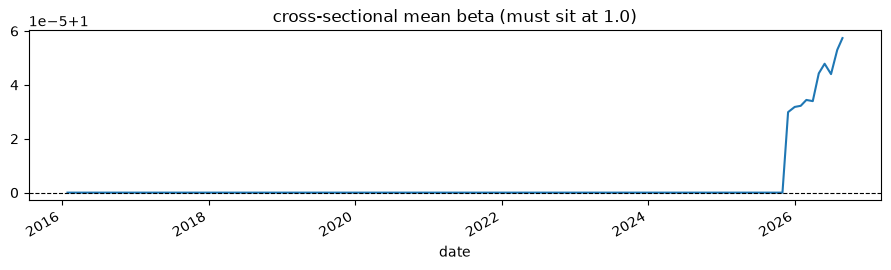

In [20]:
mb = feats["beta_252"].loc[dates].mean(axis=1)
print(mb.describe().round(4))
assert abs(mb.mean() - 1.0) < 0.05, f"mean beta is {mb.mean():.3f}, expected ~1.0"

mb.plot(figsize=(11, 2.5), title="cross-sectional mean beta (must sit at 1.0)")
plt.axhline(1 , color="k", ls="--", lw=0.8); plt.show()

2b — Idiosyncratic vol must be below total vol

In [21]:
viol = (feats["idio_vol_252"].loc[dates] > feats["vol_63"].loc[dates]).sum().sum()
tot  = feats["vol_63"].loc[dates].size
print(f"idio > total in {viol:,} of {tot:,} cells ({viol/tot:.2%})")

idio > total in 3,409 of 13,440 cells (25.36%)


2c — Drawdown must be non-positive

In [22]:
dh = feats["dist_52w_high"].loc[dates]
print("max value (must be <= 0):", dh.max().max())
print("fraction exactly at a new high:", (dh > -1e-12).to_numpy().mean().round(4))
assert dh.max().max() <= 1e-12, "positive drawdown -> window is not right-aligned"

max value (must be <= 0): 0.0
fraction exactly at a new high: 0.061


2d — Amihud and ADV must be logged

In [23]:
for f in ["amihud_63", "log_adv_63"]:
    v = feats[f].loc[dates].to_numpy().ravel()
    v = v[np.isfinite(v)]
    print(f"{f:14s} median {np.median(v):10.3f}   skew {pd.Series(v).skew():7.3f}")

amihud_63      median    -24.068   skew  -0.516
log_adv_63     median     19.634   skew   0.855


2e — Volatility must spike in March 2020

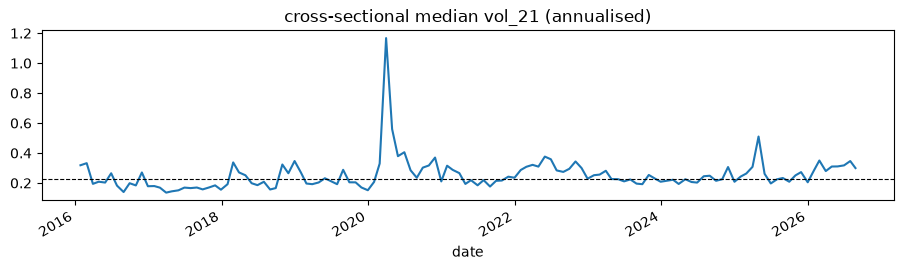

peak: 2020-03-31 1.167 | median: 0.227


In [24]:
v = feats["vol_21"].loc[dates].median(axis=1)
v.plot(figsize=(11, 2.5), title="cross-sectional median vol_21 (annualised)")
plt.axhline(v.median(), color="k", ls="--", lw=0.8); plt.show()
print("peak:", v.idxmax().date(), round(v.max(), 3), "| median:", round(v.median(), 3))

Check 3 — NaN and clipping rates

In [25]:
# NaNs at the sampling points, before any fill
nan_counts = {f: int(df.loc[dates].isna().sum().sum()) for f, df in feats.items()}
print(pd.Series(nan_counts).sort_values(ascending=False).to_string())

semivol_63          38
vol_21               0
vol_63               0
volofvol_63          0
skew_252             0
kurt_252             0
log_adv_63           0
amihud_63            0
zero_ret_frac_63     0
beta_252             0
idio_vol_252         0
mom_21               0
mom_63               0
mom_252_21           0
dist_52w_high        0


In [27]:
# Clip rate: fraction sitting exactly on the winsor bound
WINSOR = 3.0
clipped = np.isclose(np.abs(X), WINSOR, atol=1e-9)
print(f"overall clip rate: {clipped.mean():.2%}   (expect 1-4%)")
print()
print(pd.Series(clipped.mean(axis=(0, 1)), index=fnames)
        .sort_values(ascending=False).round(4).to_string())

overall clip rate: 4.39%   (expect 1-4%)

kurt_252            0.1289
skew_252            0.0768
dist_52w_high       0.0759
volofvol_63         0.0576
idio_vol_252        0.0557
semivol_63          0.0486
vol_21              0.0481
vol_63              0.0451
mom_21              0.0267
mom_252_21          0.0254
mom_63              0.0246
log_adv_63          0.0199
beta_252            0.0141
amihud_63           0.0115
zero_ret_frac_63    0.0000


Check 4 — Feature redundancy

In [28]:
T, N, F = X.shape
C = pd.DataFrame(np.corrcoef(X.reshape(T * N, F), rowvar=False),
                 index=fnames, columns=fnames)

iu = np.triu_indices(F, k=1)
pairs = (pd.DataFrame({"a": np.array(fnames)[iu[0]],
                       "b": np.array(fnames)[iu[1]],
                       "corr": C.to_numpy()[iu]})
         .assign(abs_corr=lambda x: x["corr"].abs())
         .sort_values("abs_corr", ascending=False))

print(pairs.head(10).round(3).to_string(index=False))
print("\nlog_adv_63 vs vol_21:", round(C.loc["log_adv_63", "vol_21"], 3))

         a            b   corr  abs_corr
log_adv_63    amihud_63 -0.962     0.962
    vol_63   semivol_63  0.819     0.819
    vol_63 idio_vol_252  0.806     0.806
    vol_21       vol_63  0.806     0.806
    vol_63  volofvol_63  0.680     0.680
    vol_21   semivol_63  0.675     0.675
    vol_21 idio_vol_252  0.669     0.669
semivol_63 idio_vol_252  0.630     0.630
semivol_63  volofvol_63  0.625     0.625
    vol_63     beta_252  0.605     0.605

log_adv_63 vs vol_21: 0.147


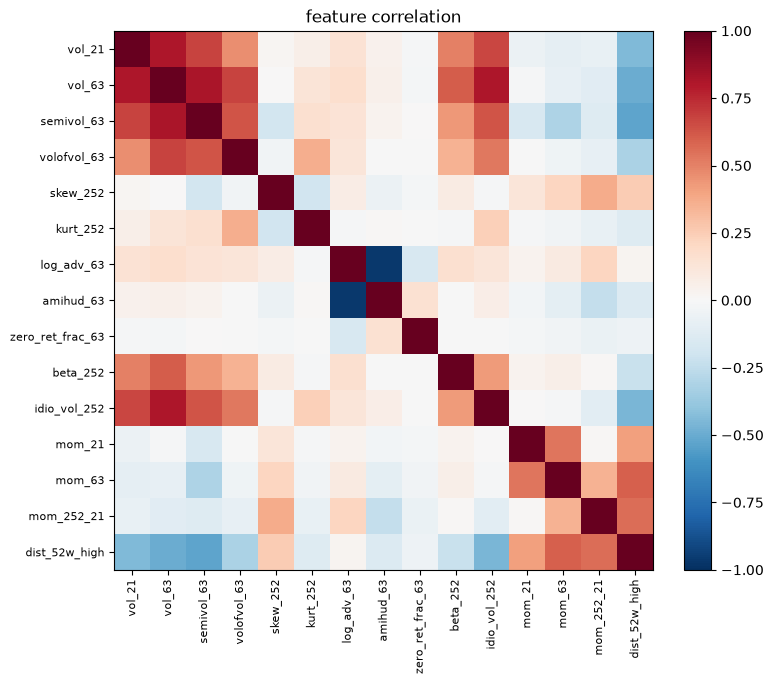

In [29]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(F)); ax.set_xticklabels(fnames, rotation=90, fontsize=8)
ax.set_yticks(range(F)); ax.set_yticklabels(fnames, fontsize=8)
plt.colorbar(im, fraction=0.046); plt.title("feature correlation"); plt.show()

Check 5 — Dead features

In [30]:
sd = pd.Series(X.std(axis=(0, 1)), index=fnames).sort_values()
print(sd.round(4).to_string())

dead = sd[sd < 0.1]
if len(dead):
    print("\nDEAD (near-zero cross-sectional variation):", list(dead.index))

zero_ret_frac_63    1.0000
amihud_63           1.0687
beta_252            1.0777
log_adv_63          1.0815
mom_63              1.1093
mom_252_21          1.1152
vol_63              1.1189
mom_21              1.1227
semivol_63          1.1339
vol_21              1.1384
idio_vol_252        1.1460
volofvol_63         1.1474
dist_52w_high       1.1864
skew_252            1.2964
kurt_252            1.3145


Check 6 — Standardisation behaved

In [31]:
med = np.median(X, axis=1)                 # [T, F] — median across tickers
print("cross-sectional median  | max |abs| :", np.abs(med).max().round(4))

scale = np.median(np.abs(X - med[:, None, :]), axis=1) * 1.4826
print("cross-sectional scale   | mean      :", scale.mean().round(4))

cross-sectional median  | max |abs| : 0.0
cross-sectional scale   | mean      : 0.9331


In [32]:
print(f"Phase 2 complete")
print(f"  X            : {X.shape}  (T x N x F)")
print(f"  date range   : {fdates[0].date()} -> {fdates[-1].date()}")
print(f"  clip rate    : {clipped.mean():.2%}")
print(f"  mean beta    : {mb.mean():.4f}")
print(f"  dead features: {list(dead.index) if len(dead) else 'none'}")
print(f"  top corr pair: {pairs.iloc[0]['a']} / {pairs.iloc[0]['b']} = {pairs.iloc[0]['corr']:.3f}")

Phase 2 complete
  X            : (128, 105, 15)  (T x N x F)
  date range   : 2016-01-29 -> 2026-08-26
  clip rate    : 4.39%
  mean beta    : 1.0000
  dead features: none
  top corr pair: log_adv_63 / amihud_63 = -0.962
